# Assignment 1: Wrangling and EDA
### Foundations of Machine Learning

In [ ]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


**Q1.** This question provides some practice cleaning variables which have common problems.
1. Numeric variable: For `airbnb_NYC.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. Categorical variable: For the Minnesota police use of for data, `mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? For the remaining missing values, replace the `np.nan/None` values with the label `Missing`.
3. Dummy variable: For `metabric.csv`, convert the `Overall Survival Status` variable into a dummy/binary variable, taking the value 0 if the patient is deceased and 1 if they are living.
4. Missing values: For `airbnb_NYC.csv`, determine how many missing values of `Review Scores Rating` there are. Create a new variable, in which you impute the median score for non-missing observations to the missing ones. Why might this bias or otherwise negatively impact your results?

1.1

In [ ]:
import pandas as pd

airbnb = pd.read_csv("/content/data/airbnb_NYC.csv", encoding='latin1')
airbnb["Price"].head()


airbnb["Price_clean"] = (
    airbnb["Price"]
    #replace non numeric symbols
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

#count the nulls in the clean price
airbnb["Price_clean"].isna().sum()

np.int64(0)

The Price variable was stored as a string due to the inclusion of symbols such as dollar signs and commas. This caused prices above $999 to include commas, which prevents direct numeric conversion. I removed dollar signs and commas before converting the variable to a numeric type. Values that could not be converted were set to missing (NaN). After cleaning, there are 0 missing values in the Price_clean variable.

1.2

In [ ]:
mn = pd.read_csv("/content/data/mn_police_use_of_force.csv")

mn["subject_injury"].value_counts(dropna=False)

# Standardize text
mn["subject_injury_clean"] = (
    mn["subject_injury"]
    .str.strip()
    .str.lower()
)

# Map to Yes / No
mn["subject_injury_clean"] = mn["subject_injury_clean"].map({
    "yes": "Yes",
    "no": "No"
})

# Proportion missing
mn["subject_injury_clean"].isna().mean()

# Replace remaining missing with label "Missing"
mn["subject_injury_clean"] = mn["subject_injury_clean"].fillna("Missing")

from IPython.display import display

ct = pd.crosstab(
    mn["force_type"],
    mn["subject_injury_clean"],
    dropna=False
)

display(ct)


mn["subject_injury_clean"].value_counts()




subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


,count
subject_injury_clean,
Missing,9848
Yes,1631
No,1446


The subject_injury variable contained missing values. I standardized the text and mapped valid responses to Yes and No in case of miscapitzalization somewhere in the data. Remaining missing values were relabeled as “Missing.” The proportion of missing values was 76.2%. Cross-tabulation with force_type suggests that missing injury data occurs more frequently for certain force types such as Bodily Force and Chemical Irritant, indicating that missingness may not be completely random.

1.3

In [ ]:
import pandas as pd

meta = pd.read_csv("/content/data/metabric.csv")
meta.head()

meta["Overall Survival Status"].value_counts(dropna=False)

meta["survival_binary"] = meta["Overall Survival Status"].map({
    "1:DECEASED": 0,
    "0:LIVING": 1
})


meta["survival_binary"].value_counts(dropna=False)


,count
survival_binary,
0,768
1,575


The Overall Survival Status variable contained string values indicating both status and numeric labels. I created a binary variable where patients labeled as “1:DECEASED” were coded as 0 and patients labeled as “0:LIVING” were coded as 1. This transformation produces a clear binary indicator that is good for analysis.

1.4

In [ ]:
import pandas as pd

airbnb = pd.read_csv("/content/data/airbnb_NYC.csv", encoding="latin1")

airbnb["Review Scores Rating"].isna().sum()

airbnb["Review Scores Rating"].median()

median_rating = airbnb["Review Scores Rating"].median()

airbnb["Review_Score_Imputed"] = airbnb["Review Scores Rating"].fillna(median_rating)

airbnb["Review_Score_Imputed"].isna().sum()



np.int64(0)

There are 0 missing values in the Review Scores Rating variable. I imputed missing values using the median review score. However, median imputation may bias results by reducing variability and hiding differences between listings with missing reviews and those with observed ratings.

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks.

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work. What does work?
2. Drop any columns that do not contain data.
3. What is an observation? Carefully justify your answer, and explain how it affects your choices in cleaning and analyzing the data.
4. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
5. Clean the Age variable and make a histogram of the ages of the victims.
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?
7. Clean the `Fatal Y/N` variable so it only takes three values: Y, N, and Unknown.
8. Is the attack more or less likely to be fatal when the attack is provoked or unprovoked? Thoughts?

Q2.1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

shark = pd.read_csv("/content/shark_attacks.csv")
shark.head()

/tmp/ipython-input-523669371.py:4: DtypeWarning: Columns (0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  shark = pd.read_csv("/content/shark_attacks.csv")


(39178, 23)

The original shark attack dataset is not distributed as a CSV file. Pandas functions such as read_excel() or read_html() could be used to load the data directly. I downloaded and converted the dataset to a CSV file, it was then loaded using read_csv().

Q2.2

In [ ]:
shark = shark.dropna(axis=1, how="all")

shark.shape


Columns that contained no data were removed to simplify the dataset and avoid unnecessary noise during analysis.

Q2.3

Each observation represents a single reported shark attack incident. This definition implies that each row corresponds to one event, and variables describe attributes of that incident.



Q2.4

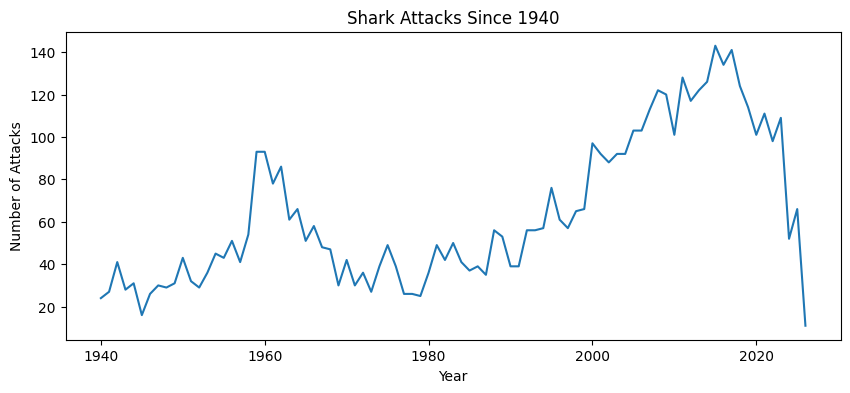

In [ ]:
# Convert Year to numeric
shark["Year_clean"] = pd.to_numeric(shark["Year"], errors="coerce")

# Inspect range
shark["Year_clean"].describe()

# Filter attacks since 1940
shark_1940 = shark[shark["Year_clean"] >= 1940]

# Attacks per year
attacks_per_year = shark_1940["Year_clean"].value_counts().sort_index()

attacks_per_year.plot(figsize=(10,4))
plt.xlabel("Year")
plt.ylabel("Number of Attacks")
plt.title("Shark Attacks Since 1940")
plt.show()


After converting the Year variable to numeric form, values ranged from the early historical record to recent years. The dataset was filtered to include attacks since 1940. The number of reported shark attacks generally increases over time with a slight spike in 1960, likely reflecting improved reporting and increased human ocean activity rather than a true rise in shark aggression.

Q2.5

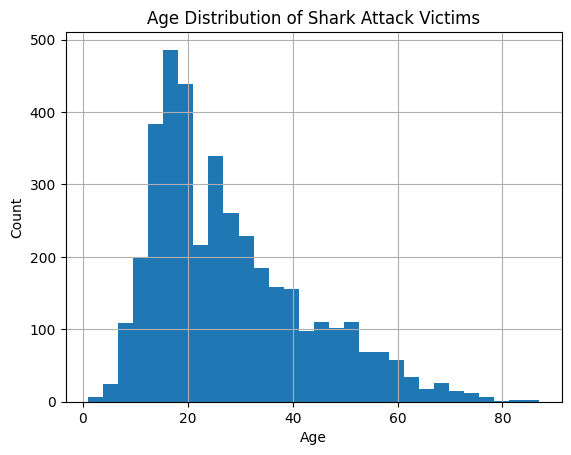

In [ ]:
# Clean Age
shark["Age_clean"] = pd.to_numeric(shark["Age"], errors="coerce")

# Plot histogram
shark["Age_clean"].dropna().hist(bins=30)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Shark Attack Victims")
plt.show()


The Age variable was cleaned by converting non-numeric values to missing. The resulting distribution shows that most shark attack victims are adolescents and adults, with fewer incidents among very young or elderly individuals.

Q2.6

In [ ]:
shark["Type_clean"] = (
    shark["Type"]
    .str.strip()
    .str.lower()
)

shark["Type_clean"] = shark["Type_clean"].where(
    shark["Type_clean"].isin(["provoked", "unprovoked"]),
    "unknown"
)

shark["Type_clean"].value_counts(normalize=True)


,proportion
Type_clean,
unknown,0.850197
unprovoked,0.133366
provoked,0.016438


The Type variable was cleaned to include only three categories: Provoked, Unprovoked, and Unknown. The majority of recorded shark attacks are unknown.

Q2.7

In [ ]:
shark["Fatal_clean"] = (
    shark["Fatal Y/N"]
    .str.strip()
    .str.upper()
)

shark["Fatal_clean"] = shark["Fatal_clean"].where(
    shark["Fatal_clean"].isin(["Y", "N"]),
    "Unknown"
)

shark["Fatal_clean"].value_counts()


,count
Fatal_clean,
Unknown,32748
N,4941
Y,1489


Q2.8

In [ ]:
pd.crosstab(
    shark["Type_clean"],
    shark["Fatal_clean"],
    normalize="index"
)


Fatal_clean,N,Unknown,Y
Type_clean,,,
provoked,0.953416,0.013975,0.032609
unknown,0.013480,0.980516,0.006004
unprovoked,0.742201,0.015120,0.242679


Unprovoked attacks are more likely to result in fatalities compared to provoked attacks. Provoked attacks often involve human interaction with sharks, which may reduce the severity of injuries, while unprovoked attacks tend to occur unexpectedly. Also an unprovoked shark implies that it is attacking the human to hunt vs deter.

**Q3.** Open the "tidy_data.pdf" document available in `https://github.com/ds4e/wrangling`, which is a paper called *Tidy Data* by Hadley Wickham.

  1. Read the abstract. What is this paper about?
  2. Read the introduction. What is the "tidy data standard" intended to accomplish?
  3. Read the intro to section 2. What does this sentence mean: "Like families, tidy datasets are all alike but every messy dataset is messy in its own way." What does this sentence mean: "For a given dataset, it’s usually easy to figure out what are observations and what are variables, but it is surprisingly difficult to precisely define variables and observations in general."
  4. Read Section 2.2. How does Wickham define values, variables, and observations?
  5. How is "Tidy Data" defined in section 2.3?
  6. Read the intro to Section 3 and Section 3.1. What are the 5 most common problems with messy datasets? Why are the data in Table 4 messy? What is "melting" a dataset?
  7. Why, specifically, is table 11 messy but table 12 tidy and "molten"?

3.1

The paper introduces the concept of tidy data and explains why a consistent data structure is essential for effective data analysis. Wickham states that many real-world datasets are messy in predictable ways and proposes a standardized framework for organizing data to make analysis, visualization, and modeling easier and more reproducible.

3.2

The tidy data standard is intended to provide a consistent and logical structure for datasets so that each variable, observation, and value is clearly defined. This standard reduces ambiguity, simplifies data manipulation, and allows analytical tools to work together more efficiently.

3.3

a. “Like families, tidy datasets are all alike but every messy dataset is messy in its own way.”

This means that tidy datasets all follow the same structural rules, while messy datasets can be disorganized in many different and inconsistent ways. Messiness does not follow a single pattern, making cleaning more difficult.

b. “For a given dataset, it’s usually easy to figure out what are observations and what are variables…”

This means that while humans can often intuitively understand what a dataset represents, it is much harder to formally and consistently define observations and variables in a way that works across different datasets and analyses.

3.4

*   Values are individual data points.
*   Variables are measured attributes that can take different values.
*   Observations are collections of values measured across variables for a single unit.

3.5

A dataset is tidy when:

1.   Each variable forms a column
2.   Each observation forms a row
3.   Each type of observational unit forms a table

3.6

a. Five most common problems:
1.   Column headers are values, not variable names
2.   Multiple variables stored in one column
3.   Variables stored in both rows and columns
4.   Multiple observational units in the same table
5.   A single observational unit stored across multiple tables

b. Why is Table 4 messy?

Table 4 is messy because values that belong to a single variable are spread across multiple columns, violating tidy data principles.

c. What is “melting” a dataset?

Melting converts data from a wide format to a long format by collapsing columns into rows, making variables explicit and restoring tidy structure.

3.7

Table 11 is messy because variable values are encoded in column names rather than in a single variable column. Table 12 is tidy and molten because it has been reshaped so that each variable has its own column and each observation occupies its own row.

**Q4.** This question looks at financial transfers from international actors to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going?

For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
5. What are the top 15 institutions in terms of the total amount of money they receive? Make a histogram of the total amount received by all institutions.
6. Which giftors provide the most money, in total?

4.1

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

fg = pd.read_csv("/content/data/ForeignGifts_edu.csv")
fg.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


4.2

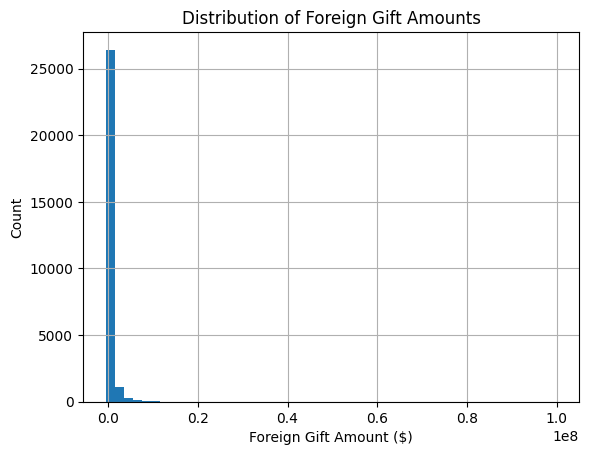

In [5]:
fg["Foreign Gift Amount"] = pd.to_numeric(
    fg["Foreign Gift Amount"], errors="coerce"
)

fg["Foreign Gift Amount"].dropna().hist(bins=50)
plt.xlabel("Foreign Gift Amount ($)")
plt.ylabel("Count")
plt.title("Distribution of Foreign Gift Amounts")
plt.show()


The distribution of foreign gift amounts is highly right-skewed. Most gifts are relatively small, while a small number of very large gifts account for a disproportionate share of the total value. This indicates substantial inequality in gift sizes.

4.3

In [6]:
gift_type_counts = fg["Gift Type"].value_counts(normalize=True)
gift_type_counts


,proportion
Gift Type,
Contract,0.612097
Monetary Gift,0.387513
Real Estate,0.000390


4.4

In [10]:
top_countries_count = (
    fg.groupby("Country of Giftor")
      .count()["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)

top_countries_count


,Foreign Gift Amount
Country of Giftor,
ENGLAND,3655
CHINA,2461
CANADA,2344
JAPAN,1896
SWITZERLAND,1676
SAUDI ARABIA,1610
FRANCE,1437
GERMANY,1394
HONG KONG,1080


In [11]:
top_countries_amount = (
    fg.groupby("Country of Giftor")
      .sum(numeric_only=True)["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)

top_countries_amount


,Foreign Gift Amount
Country of Giftor,
QATAR,2706240869
ENGLAND,1464906771
CHINA,1237952112
SAUDI ARABIA,1065205930
BERMUDA,899593972
CANADA,898160656
HONG KONG,887402529
JAPAN,655954776
SWITZERLAND,619899445


4.5

In [16]:
top_institutions = (
    fg.groupby("Institution Name")
      .sum(numeric_only=True)["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)

top_institutions

,Foreign Gift Amount
Institution Name,
Carnegie Mellon University,1477922504
Cornell University,1289937761
Harvard University,954803610
Massachusetts Institute of Technology,859071692
Yale University,613441311
Texas A&M University,521455050
Johns Hopkins University,502409595
Northwestern University,402316221
Georgetown University,379950511


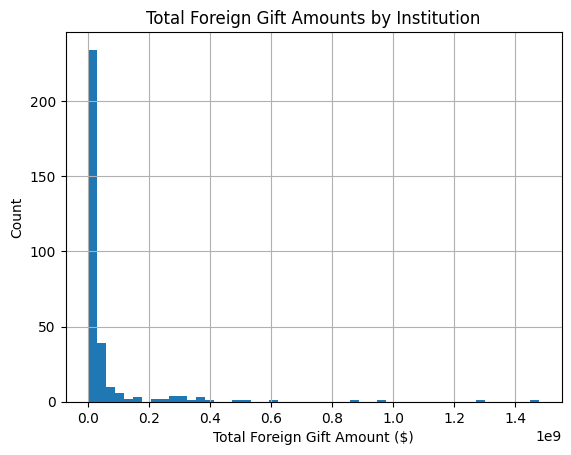

In [17]:
institution_totals = (
    fg.groupby("Institution Name")
      .sum(numeric_only=True)["Foreign Gift Amount"]
)

institution_totals.hist(bins=50)
plt.xlabel("Total Foreign Gift Amount ($)")
plt.ylabel("Count")
plt.title("Total Foreign Gift Amounts by Institution")
plt.show()


4.6

In [15]:
top_giftors = (
    fg.groupby("Giftor Name")
      .sum(numeric_only=True)["Foreign Gift Amount"]
      .sort_values(ascending=False)
      .head(15)
)

top_giftors


,Foreign Gift Amount
Giftor Name,
Qatar Foundation,1166503744
Qatar Foundation/Qatar National Res,796197000
Qatar Foundation for Education,373945215
Anonymous,338793629
Saudi Arabian Cultural Mission,275221475
HCL,190000000
Church of Jesus Christ of LDS,185203715
Emirates Institute for Advanced Sc,170641244
QIC,148355497


**Q5.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `college_completion.csv` dataset from the US Department of Education. The "relevant" variables for this question are:
  - `level` - Level of institution (4-year, 2-year)
  - `aid_value` - The average amount of student aid going to undergraduate recipients
  - `control` - Public, Private not-for-profit, Private for-profit
  - `grad_100_value` - percentage of first-time, full-time, degree-seeking undergraduates who complete a degree or certificate program within 100 percent of expected time (bachelor's-seeking group at 4-year institutions)

1. Load the `college_completion.csv` data with Pandas.
2. How many observations and variables are in the data? Use `.head()` to examine the first few rows of data.
3. Cross tabulate `control` and `level`. Describe the patterns you see in words.
4. For `grad_100_value`, create a kernel density plot and describe table. Now condition on `control`, and produce a kernel density plot and describe tables for each type of institutional control. Which type of institution appear to have the most favorable graduation rates?
5. Make a scatterplot of `grad_100_value` by `aid_value`, and compute the covariance and correlation between the two variables. Describe what you see. Now make the same plot and statistics, but conditioning on `control`. Describe what you see. For which kinds of institutions does aid seem to vary positively with graduation rates?

5.1

In [18]:
college = pd.read_csv("/content/data/college_completion.csv")
college.head()

,index,unitid,chronname,city,state,level,control,basic,hbcu,flagship,...,vsa_grad_after6_transfer,vsa_grad_elsewhere_after6_transfer,vsa_enroll_after6_transfer,vsa_enroll_elsewhere_after6_transfer,similar,state_sector_ct,carnegie_ct,counted_pct,nicknames,cohort_size
0,0,100654,Alabama A&M University,Normal,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,36.4,5.6,17.2,11.1,232937|100724|405997|113607|139533|144005|2285...,13,386,99.7|07,NaN,882.0
1,1,100663,University of Alabama at Birmingham,Birmingham,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,NaN,NaN,NaN,NaN,196060|180461|201885|145600|209542|236939|1268...,13,106,56.0|07,UAB,1376.0
2,2,100690,Amridge University,Montgomery,Alabama,4-year,Private not-for-profit,Baccalaureate Colleges--Arts & Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,217925|441511|205124|247825|197647|221856|1353...,16,252,100.0|07,NaN,3.0
3,3,100706,University of Alabama at Huntsville,Huntsville,Alabama,4-year,Public,Research Universities--very high research acti...,NaN,NaN,...,0.0,0.0,0.0,0.0,232186|133881|196103|196413|207388|171128|1900...,13,106,43.1|07,UAH,759.0
4,4,100724,Alabama State University,Montgomery,Alabama,4-year,Public,Masters Colleges and Universities--larger prog...,X,NaN,...,NaN,NaN,NaN,NaN,100654|232937|242617|243197|144005|241739|2354...,13,386,88.0|07,ASU,1351.0


5.2

In [19]:
college.shape

(3798, 63)

The dataset contains 3798 observations and 63 variables. Examining the first few rows shows that each observation represents an individual institution, with variables describing institutional characteristics, student aid, and graduation outcomes.

5.3

In [20]:
pd.crosstab(college["control"], college["level"])

level,2-year,4-year
control,,
Private for-profit,465,527
Private not-for-profit,68,1180
Public,926,632


Public institutions are disproportionately represented among 2-year colleges, while private not-for-profit institutions are overwhelmingly 4-year institutions. Private for-profit institutions appear at both levels but are more evenly split. This reflects structural differences in institutional missions and funding models.

5.4

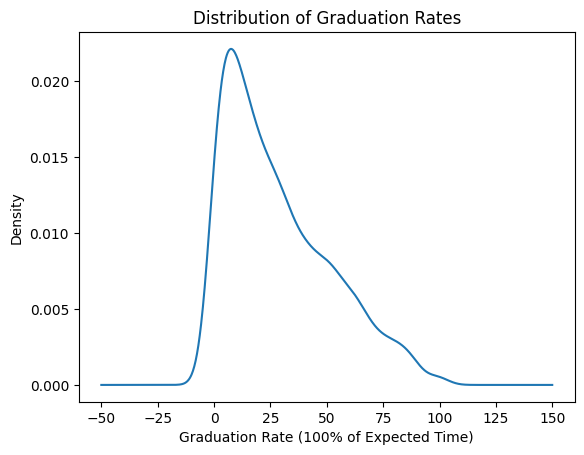

In [21]:
college["grad_100_value"].dropna().plot(kind="kde")
plt.xlabel("Graduation Rate (100% of Expected Time)")
plt.title("Distribution of Graduation Rates")
plt.show()


In [22]:
college["grad_100_value"].describe()


,grad_100_value
count,3467.000000
mean,28.364465
std,23.312730
min,0.000000
25%,9.000000
50%,22.500000
75%,43.650000
max,100.000000


In [23]:
college.groupby("control")["grad_100_value"].describe()


,count,mean,std,min,25%,50%,75%,max
control,,,,,,,,
Private for-profit,779.0,29.108858,25.601687,0.0,6.95,24.7,46.75,100.0
Private not-for-profit,1189.0,41.660976,23.551231,0.0,25.00,41.0,58.30,100.0
Public,1499.0,17.430887,14.729443,0.0,6.90,13.2,23.25,97.8


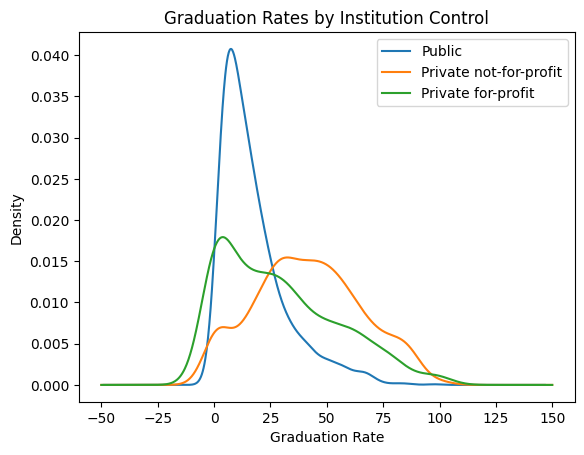

In [24]:
for c in college["control"].dropna().unique():
    college.loc[college["control"] == c, "grad_100_value"].dropna().plot(
        kind="kde", label=c
    )

plt.legend()
plt.xlabel("Graduation Rate")
plt.title("Graduation Rates by Institution Control")
plt.show()


Graduation rates vary substantially across institutions. Private not-for-profit institutions tend to have the highest graduation rates, followed by public institutions. Private for-profit institutions generally have lower graduation rates. This pattern is consistent across both the distributional plots and summary statistics.

5.5

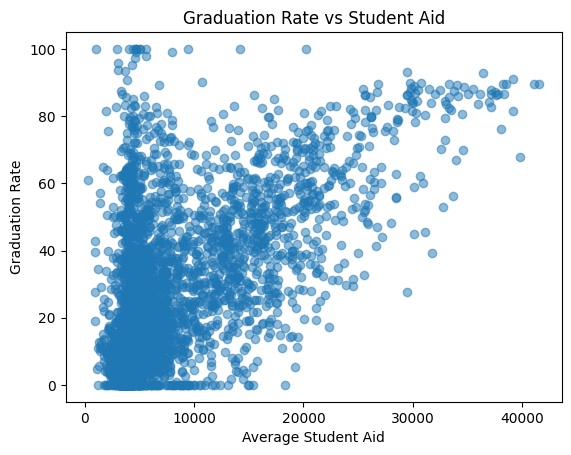

In [25]:
plt.scatter(college["aid_value"], college["grad_100_value"], alpha=0.5)
plt.xlabel("Average Student Aid")
plt.ylabel("Graduation Rate")
plt.title("Graduation Rate vs Student Aid")
plt.show()


In [26]:
college[["aid_value", "grad_100_value"]].cov()


,aid_value,grad_100_value
aid_value,4.121201e+07,88610.483169
grad_100_value,8.861048e+04,543.483382


In [27]:
college[["aid_value", "grad_100_value"]].corr()


,aid_value,grad_100_value
aid_value,1.000000,0.575879
grad_100_value,0.575879,1.000000


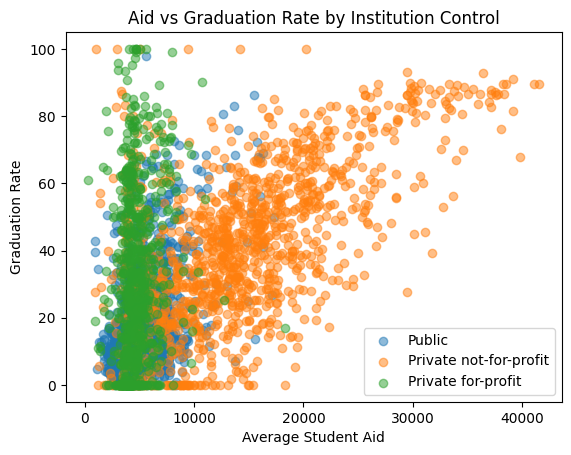

In [28]:
for c in college["control"].dropna().unique():
    subset = college[college["control"] == c]

    plt.scatter(subset["aid_value"], subset["grad_100_value"], alpha=0.5, label=c)

plt.legend()
plt.xlabel("Average Student Aid")
plt.ylabel("Graduation Rate")
plt.title("Aid vs Graduation Rate by Institution Control")
plt.show()


In [29]:
college.groupby("control")[["aid_value", "grad_100_value"]].corr()


aid_value  grad_100_value
control                                                         
Private for-profit     aid_value        1.000000        0.188363
                       grad_100_value   0.188363        1.000000
Private not-for-profit aid_value        1.000000        0.601591
                       grad_100_value   0.601591        1.000000
Public                 aid_value        1.000000        0.482481
                       grad_100_value   0.482481        1.000000

Overall, student aid and graduation rates exhibit a positive but modest correlation. When conditioning on institutional control, the relationship appears strongest for private not-for-profit institutions, where higher aid levels are more consistently associated with higher graduation rates. The relationship is weaker and more variable among public and for-profit institutions.

**Q6.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

We're going to look at **linear transformations** of $X$, $Y = a + bX$. So we take each value of $X$, $x_i$, and transform it as $y_i = a + b x_i$.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $ \text{cov}(X,X) = s^2$.
3. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
4. Show that $\text{cov}(a+bX,a+bY) = b^2 \text{cov}(X,Y) $. Notice, this also means that $\text{cov}(bX, bX) = b^2 s^2$.
5. Suppose $b>0$ and let the median of $X$ be $\text{med}(X)$. Is it true that the median of $a+bX$ is equal to $a + b \times \text{med}(X)$? Is the IQR of $a + bX$ equal to $a + b \times \text{IQR}(X)$?
6. Show by example that the means of $X^2$ and $\sqrt{X}$ are generally not $(m(X))^2$ and $\sqrt{m(X)}$. So, the results we derived above really depend on the linearity of the transformation $Y = a + bX$, and transformations like $Y = X^2$ or $Y = \sqrt{X}$ will not behave in a similar way.

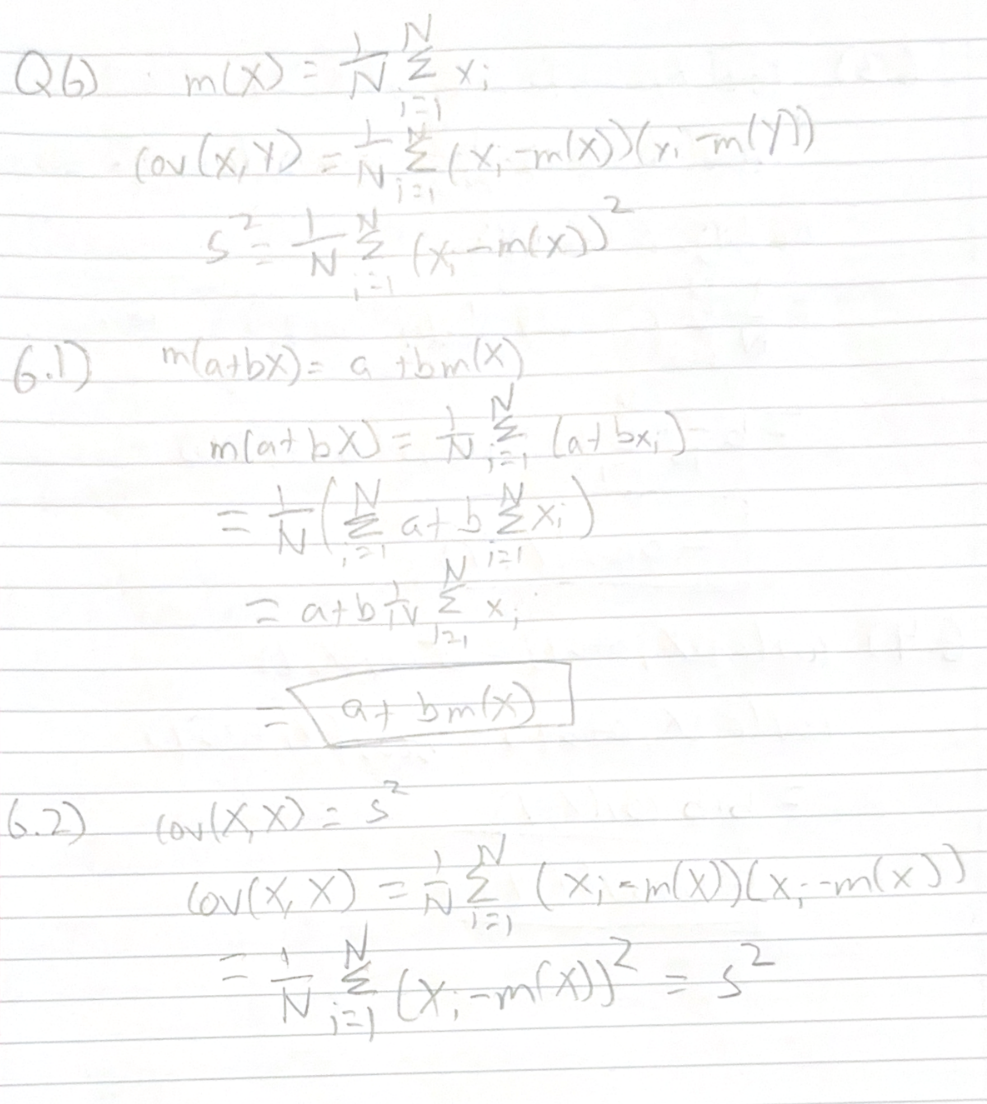

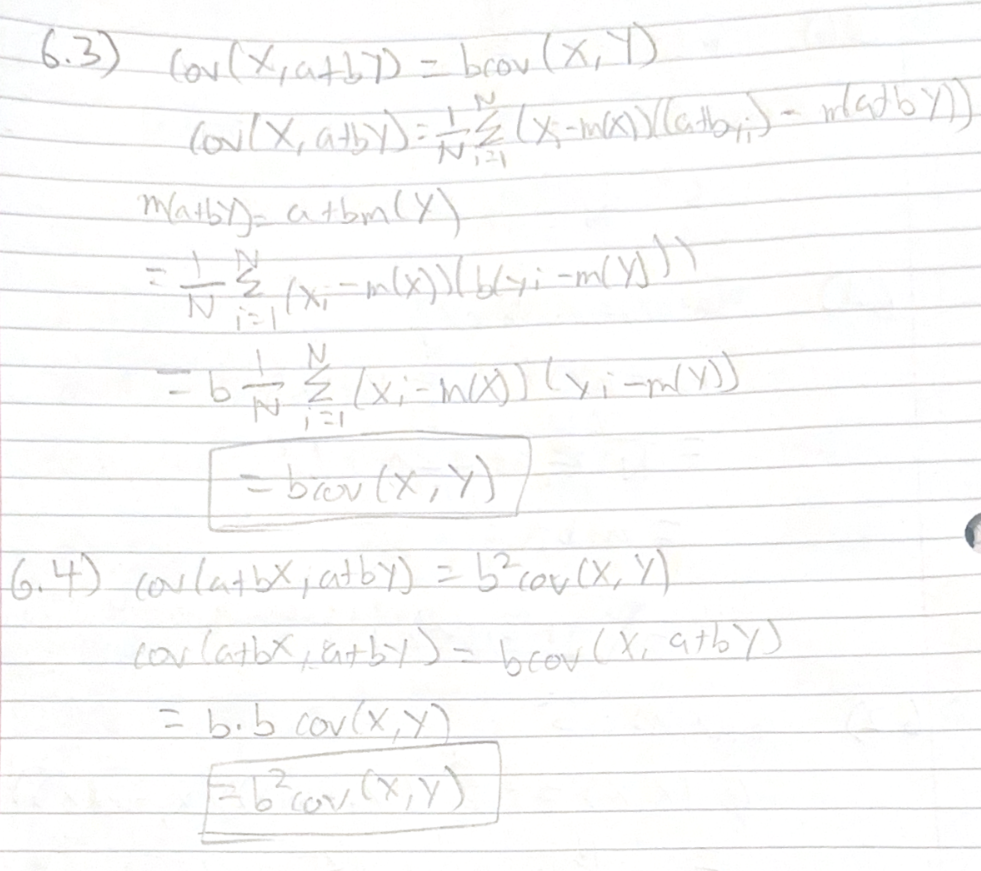

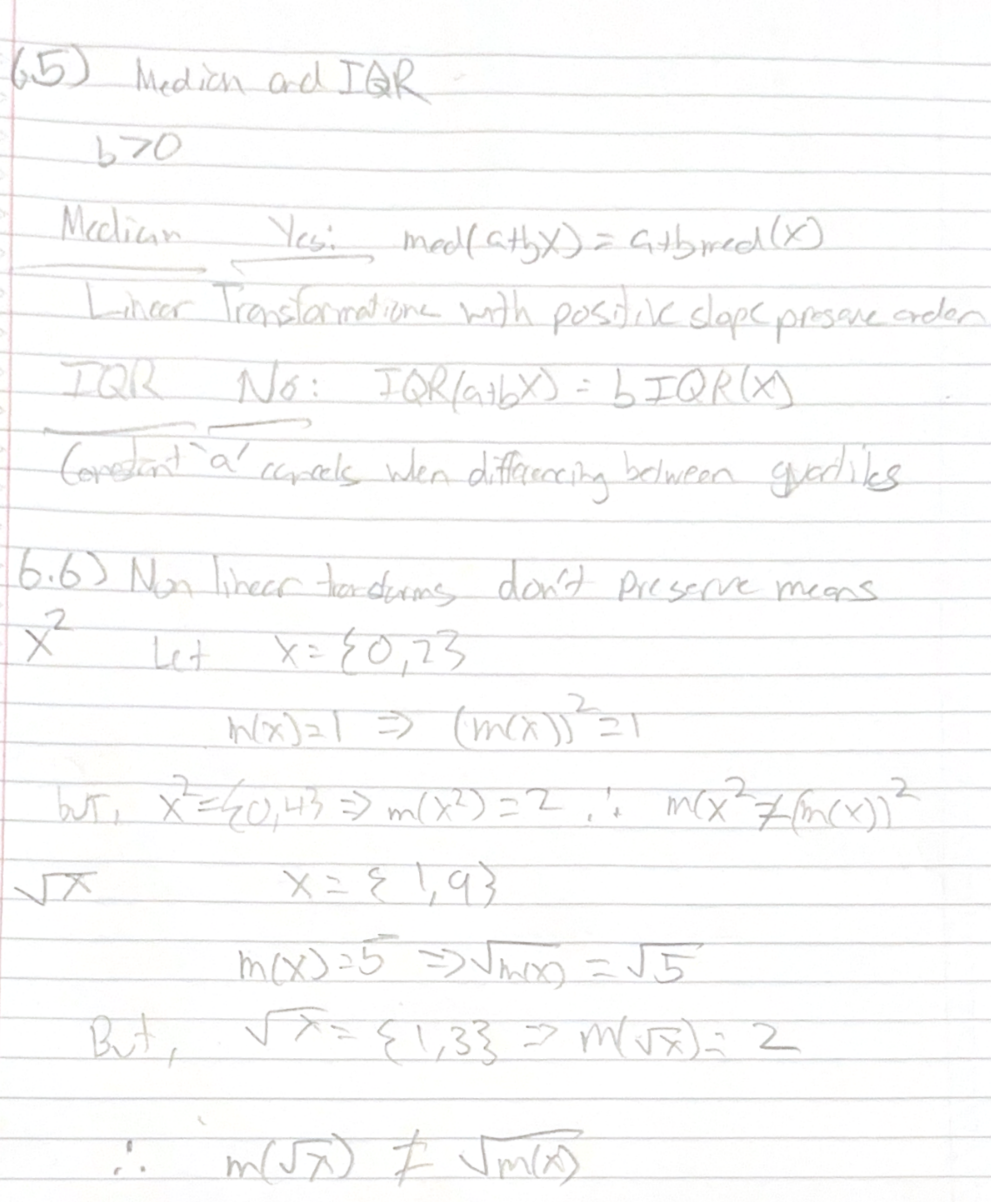

**Q7.** This question provides some practice doing exploratory data analysis and visualization.

We'll use the `ames_prices.csv` dataset. The "relevant" variables for this question are:
  - `price` - Sale price value of the house
  - `Bldg.Type` - Building type of the house (single family home, end-of-unit townhome, duplex, interior townhome, two-family conversion)

1. Load the `college_completion.csv` data with Pandas.
2. Make a kernel density plot of price and compute a describe table. Now, make a kernel density plot of price conditional on building type, and use `.groupby()` to make a describe type for each type of building. Which building types are the most expensive, on average? Which have the highest variance in transaction prices?
3. Make an ECDF plot of price, and compute the sample minimum, .25 quantile, median, .75 quantile, and sample maximum (i.e. a 5-number summary).
4. Make a boxplot of price. Are there outliers? Make a boxplot of price conditional on building type. What patterns do you see?
5. Make a dummy variable indicating that an observation is an outlier.
6. Winsorize the price variable, and compute a new kernel density plot and describe table. How do the results change?

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


7.1

In [31]:
ames = pd.read_csv("/content/data/ames_prices.csv")
ames.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


7.2

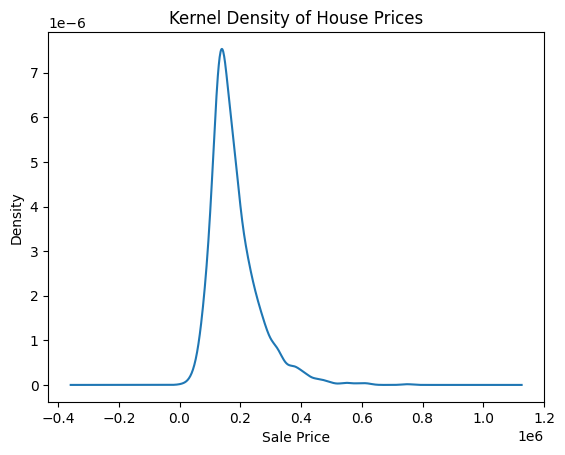

In [32]:
ames["price"].plot(kind="kde")
plt.xlabel("Sale Price")
plt.title("Kernel Density of House Prices")
plt.show()

In [33]:
ames["price"].describe()

,price
count,2930.000000
mean,180796.060068
std,79886.692357
min,12789.000000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,755000.000000


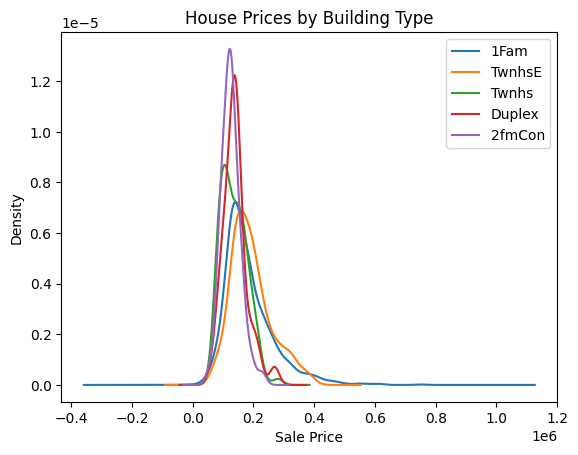

In [34]:
for b in ames["Bldg.Type"].dropna().unique():
    ames.loc[ames["Bldg.Type"] == b, "price"].plot(
        kind="kde", label=b
    )

plt.legend()
plt.xlabel("Sale Price")
plt.title("House Prices by Building Type")
plt.show()


In [35]:
ames.groupby("Bldg.Type")["price"].describe()


,count,mean,std,min,25%,50%,75%,max
Bldg.Type,,,,,,,,
1Fam,2425.0,184812.041237,82821.802329,12789.0,130000.0,165000.0,220000.0,755000.0
2fmCon,62.0,125581.709677,31089.239840,55000.0,106562.5,122250.0,140000.0,228950.0
Duplex,109.0,139808.935780,39498.973534,61500.0,118858.0,136905.0,153337.0,269500.0
Twnhs,101.0,135934.059406,41938.931130,73000.0,100500.0,130000.0,170000.0,280750.0
TwnhsE,233.0,192311.914163,66191.738021,71000.0,145000.0,180000.0,222000.0,392500.0


Single-family homes have the highest average sale prices and the greatest variance, reflecting a wide range of sizes and qualities. Townhomes and duplexes tend to have lower average prices and less dispersion. This suggests that detached single-family homes dominate the upper end of the price distribution.

7.3

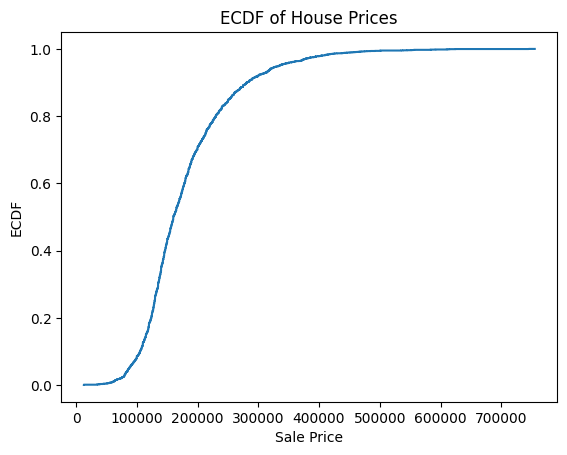

In [36]:
prices_sorted = np.sort(ames["price"])
ecdf = np.arange(1, len(prices_sorted) + 1) / len(prices_sorted)

plt.step(prices_sorted, ecdf)
plt.xlabel("Sale Price")
plt.ylabel("ECDF")
plt.title("ECDF of House Prices")
plt.show()


In [37]:
ames["price"].quantile([0, 0.25, 0.5, 0.75, 1.0])


,price
0.00,12789.0
0.25,129500.0
0.50,160000.0
0.75,213500.0
1.00,755000.0


The ECDF shows a highly right-skewed distribution of housing prices. The five-number summary highlights a large gap between the upper quartile and the maximum, indicating the presence of high-priced outliers.

7.4

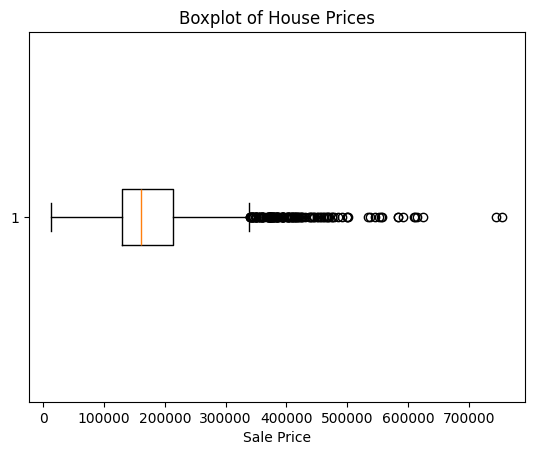

In [38]:
plt.boxplot(ames["price"], vert=False)
plt.xlabel("Sale Price")
plt.title("Boxplot of House Prices")
plt.show()


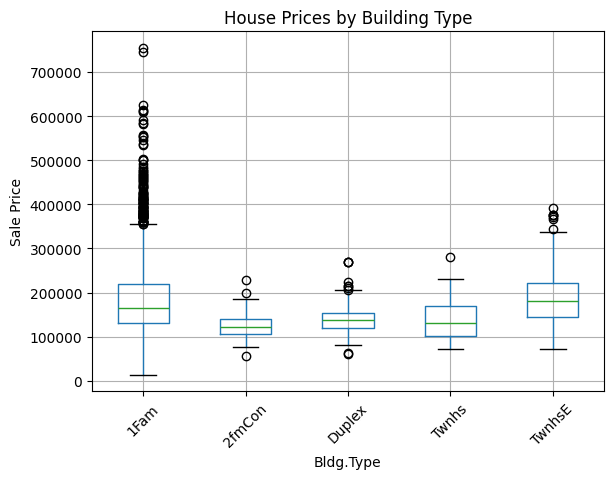

In [39]:
ames.boxplot(column="price", by="Bldg.Type", rot=45)
plt.title("House Prices by Building Type")
plt.suptitle("")
plt.ylabel("Sale Price")
plt.show()


The boxplot reveals numerous high-price outliers, particularly among single-family homes. When conditioning on building type, single-family homes show both higher medians and more extreme outliers compared to other housing types.

7.5

In [40]:
Q1 = ames["price"].quantile(0.25)
Q3 = ames["price"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

ames["price_outlier"] = (
    (ames["price"] < lower) | (ames["price"] > upper)
).astype(int)

ames["price_outlier"].value_counts()


,count
price_outlier,
0,2793
1,137


An outlier indicator was created using the 1.5 × IQR rule. Observations with prices far above the upper quartile were flagged as outliers, capturing extreme high-value transactions.

7.6

In [41]:
lower_w = ames["price"].quantile(0.01)
upper_w = ames["price"].quantile(0.99)

ames["price_winsor"] = ames["price"].clip(lower=lower_w, upper=upper_w)


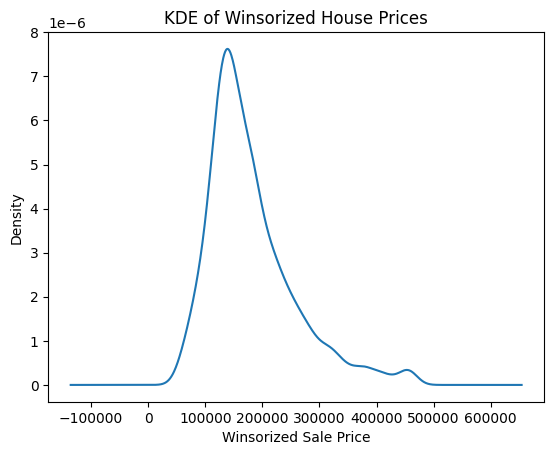

In [42]:
ames["price_winsor"].plot(kind="kde")
plt.xlabel("Winsorized Sale Price")
plt.title("KDE of Winsorized House Prices")
plt.show()


In [43]:
ames["price_winsor"].describe()


,price_winsor
count,2930.000000
mean,180091.154334
std,75842.579174
min,61756.070000
25%,129500.000000
50%,160000.000000
75%,213500.000000
max,456666.370000


Winsorizing the price variable reduces the influence of extreme outliers, leading to a less skewed distribution and smaller variance. Central tendency measures such as the median remain largely unchanged, while the mean becomes more representative of typical housing prices.